<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/00_AED_exploratoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB00 — Análise Exploratória de Dados (AED)

## 1. Contexto

Este notebook reúne a análise exploratória de dados do pipeline oficial revisado, com foco
em caracterizar:
- o dado de origem operacional disponível;
- a série temporal agregada;
- os episódios críticos;
- os estados operacionais;
- e a estrutura inicial do problema supervisionado de antecipação.

Sua função é separar a etapa de exploração e entendimento dos dados da etapa de modelagem
supervisionada, permitindo maior clareza metodológica no artigo e na dissertação.

## 2. Objetivo

Os objetivos deste notebook são:
- caracterizar o dado de origem representado em `google_trace_clean.parquet`;
- descrever a distribuição temporal básica dos registros, eventos e falhas;
- examinar a cobertura temporal e o comportamento do bloco inicial da série;
- caracterizar os artefatos principais já produzidos pelo pipeline oficial;
- descrever a distribuição temporal dos eventos agregados, falhas e da taxa de falha;
- analisar os episódios críticos detectados;
- explorar a distribuição dos estados operacionais;
- inspecionar a base supervisionada de antecipação construída no NB06;
- gerar gráficos e tabelas descritivas úteis para o artigo e para a dissertação.

## 3. Papel no Pipeline Atualizado

Este notebook não altera os artefatos do pipeline principal.

Seu papel é:
- fornecer evidência exploratória e interpretativa para o trabalho;
- apoiar a justificativa metodológica das escolhas feitas nos notebooks NB04, NB05 e NB06;
- consolidar a AED como etapa própria, anterior à modelagem do NB08 e à consolidação do NB09.

## 4. Artefatos Utilizados

Este notebook utiliza, quando disponíveis:
- `google_trace_clean.parquet`
- `window_5min_series.parquet`
- `window_5min_series_scored.parquet`
- `episodes_detected.parquet`
- `window_5min_features.parquet`
- `window_5min_labeled.parquet`
- `anticipation_supervised_dataset.parquet`
- `transition_dataset.parquet` (nome legado, apenas como fallback)

## 5. Eixos da Análise

A análise exploratória será organizada em seis eixos:
1. dado de origem operacional (clean);
2. visão geral dos artefatos do pipeline;
3. comportamento temporal da série agregada e da taxa de falha;
4. distribuição dos episódios críticos;
5. estados operacionais e dinâmica de transição;
6. estrutura inicial do problema supervisionado de antecipação.

## 6. Relação com as Próximas Etapas

Os achados deste notebook ajudam a sustentar:
- a interpretação do dado de origem utilizado no pipeline;
- a definição de criticidade por taxa no NB04;
- a engenharia de atributos do NB05;
- a formulação supervisionada do NB06;
- a modelagem principal do NB08;
- a consolidação editorial do NB09.

## 7. Observações Metodológicas

- este notebook tem caráter descritivo e interpretativo;
- ele não substitui os notebooks de processamento e modelagem;
- sua função principal é melhorar a legibilidade científica do trabalho;
- sempre que possível, as análises são feitas com base nos artefatos já persistidos pelo pipeline;
- a AED do dado de origem é realizada sobre `google_trace_clean.parquet`, isto é, sobre a
  base de eventos já limpa e normalizada que efetivamente alimenta o restante do pipeline;
- a leitura final dos resultados deve ser compatível com a versão oficial revisada do pipeline.

[Bootstrap] Google Drive já montado.
PROCESSED_PATH = /content/drive/MyDrive/Mestrado/02-datasets/02-processed
FEATURES_PATH  = /content/drive/MyDrive/Mestrado/02-datasets/03-features
REPORTS_PATH   = /content/drive/MyDrive/Mestrado/04-reports
[NB00_AED] Lendo: /content/drive/MyDrive/Mestrado/02-datasets/02-processed/google_trace_clean.parquet
[NB00_AED] Lendo: /content/drive/MyDrive/Mestrado/02-datasets/03-features/window_5min_series.parquet
[NB00_AED] Lendo: /content/drive/MyDrive/Mestrado/02-datasets/03-features/window_5min_series_scored.parquet
[NB00_AED] Lendo: /content/drive/MyDrive/Mestrado/02-datasets/03-features/episodes_detected.parquet
[NB00_AED] Lendo: /content/drive/MyDrive/Mestrado/02-datasets/03-features/window_5min_features.parquet
[NB00_AED] Lendo: /content/drive/MyDrive/Mestrado/02-datasets/03-features/window_5min_labeled.parquet
[NB00_AED] Lendo: /content/drive/MyDrive/Mestrado/02-datasets/03-features/anticipation_supervised_dataset.parquet
[NB00_AED] Lendo summary: 

,time,collection_id,scheduling_class,priority,instance_index,machine_id,resource_request,scheduler,start_time,end_time,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cluster,event,failed,t_rel_us,hour
0,0,35039733202,3,200,3422,32200095097,"{'cpus': 0.0016727447509765625, 'memory': 0.00...",0.0,1043400000000,1043700000000,...,0.000000,3.700256e-04,2.396871,0.015681,1.0,5,FAIL,1,0,0
1,0,36195154546,3,200,5215,1350632222,"{'cpus': 0.00405120849609375, 'memory': 0.0014...",0.0,1988700000000,1989000000000,...,0.000000,2.889633e-04,3.491811,0.027028,1.0,8,FAIL,1,0,0
2,0,156608140145,2,215,1188,34377813812,"{'cpus': 0.0167236328125, 'memory': 0.01965332...",0.0,695700000000,696000000000,...,0.000000,9.536743e-07,2.374518,0.021636,1.0,5,FAIL,1,0,0
3,0,4741149133,2,200,5583,13383877823,"{'cpus': 0.0016727447509765625, 'memory': 0.00...",0.0,1302900000000,1303200000000,...,0.000435,4.768372e-06,1.918681,0.004983,1.0,6,FAIL,1,0,0
4,0,748672561728,0,103,5406,303357450,"{'cpus': 0.0008096694946289062, 'memory': 0.00...",1.0,2442000000000,2442300000000,...,0.002277,6.294250e-05,3.171510,0.016618,1.0,4,ENABLE,0,0,0



[Resumo básico do dado de origem clean]


,rows,cols,time_min,time_max,t_rel_us_min,t_rel_us_max,hour_min,hour_max,n_unique_machine_id,n_unique_collection_id,resource_request_presence_rate,rows_hour0,pct_hour0,failed_sum_hour0
0,405891,23,0,2678923967375,0,2678923967375,0,744,96174,4057,0.998093,56740,0.139791,37150



[Distribuição de event]


,count
event,
FINISH,92864
FAIL,92678
ENABLE,75907
SCHEDULE,69104
LOST,59515
EVICT,14756
KILL,951
UPDATE_PENDING,111
QUEUE,4


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_00_event_distribution.png


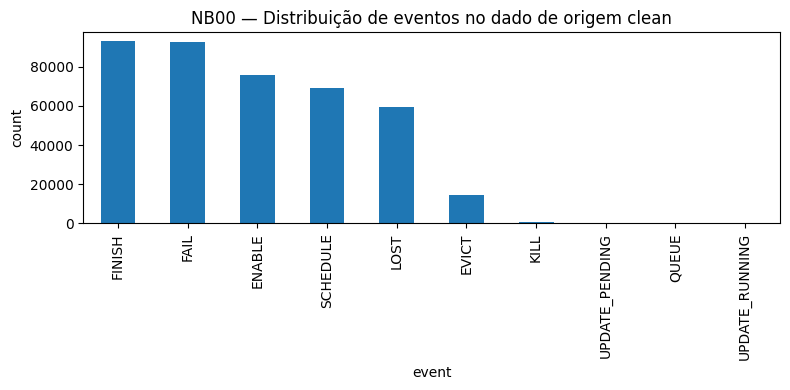


[Distribuição de failed]


,count
failed,
0,313213
1,92678


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_00_failed_distribution.png


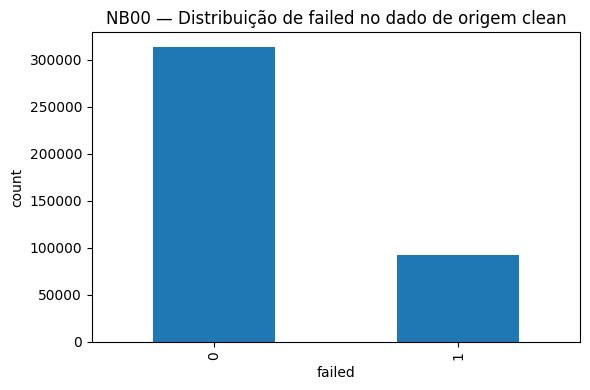


[Distribuição de scheduling_class]


,count
scheduling_class,
0,120414
1,105329
2,131567
3,48581


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_00_scheduling_class_distribution.png


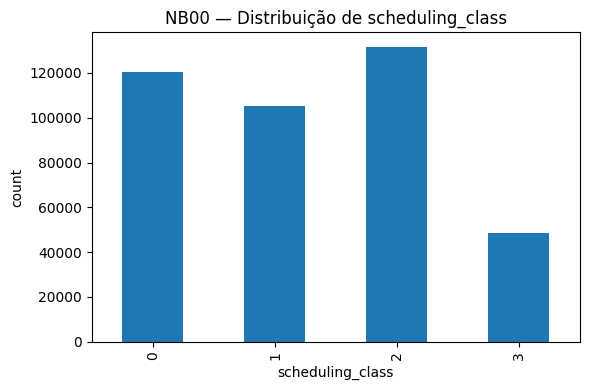


[Estatísticas de priority]


,priority_mean,priority_median,priority_std,priority_min,priority_max
0,147.913408,105.0,116.656834,0.0,450.0


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_00_priority_hist.png


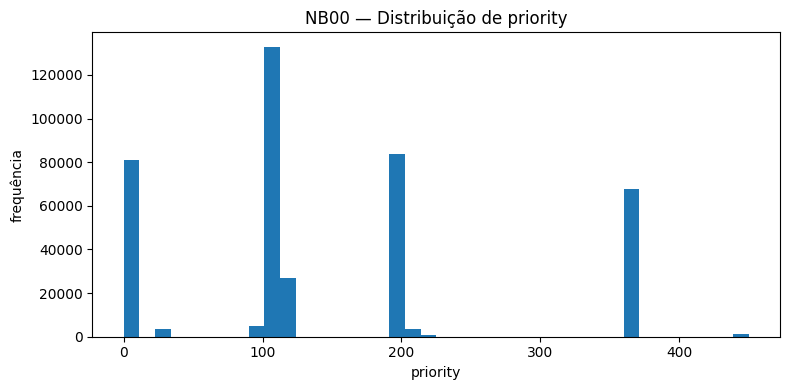


[Volume de registros por hour]


,count
hour,
0,56740
1,372
2,450
3,459
4,594
5,612
6,1016
7,896
8,868


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_00_hour_distribution.png


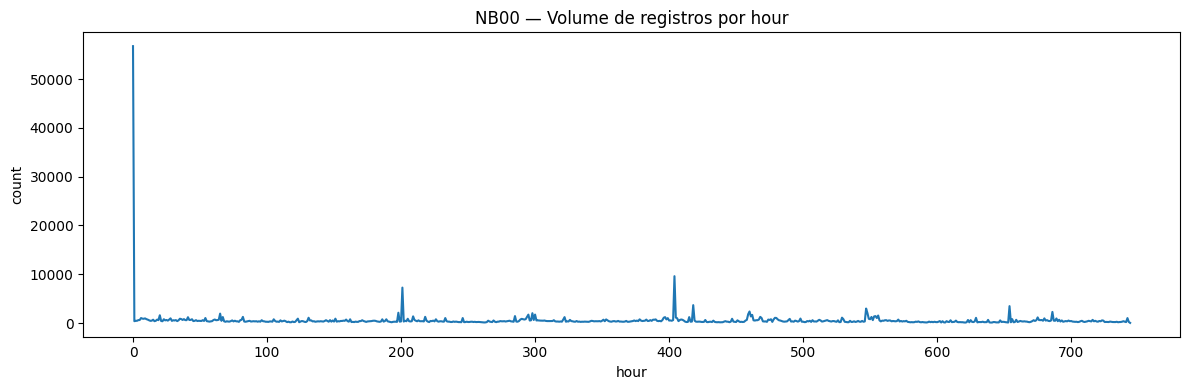


[Distribuição de event em hour == 0]


,count
event,
FAIL,37150
ENABLE,18682
FINISH,666
SCHEDULE,161
LOST,78
KILL,3
EVICT,0
QUEUE,0
UPDATE_PENDING,0



===== window_5min_series =====
shape: (8930, 18)
columns: ['bucket_id', 'bucket_start_us', 'n_events', 'n_failed', 'n_machines', 'n_collections', 'mean_priority', 'mean_req_cpus', 'mean_req_mem', 'req_cpus_presence_rate', 'req_mem_presence_rate', 'event_FAIL_count', 'event_SCHEDULE_count', 'event_FINISH_count', 'event_ENABLE_count', 'event_LOST_count', 'event_EVICT_count', 'event_KILL_count']


,bucket_id,bucket_start_us,n_events,n_failed,n_machines,n_collections,mean_priority,mean_req_cpus,mean_req_mem,req_cpus_presence_rate,req_mem_presence_rate,event_FAIL_count,event_SCHEDULE_count,event_FINISH_count,event_ENABLE_count,event_LOST_count,event_EVICT_count,event_KILL_count
0,0,0,56452,37082,43394,1232,166.682739,0.018434,0.009607,0.986289,0.986289,37082,154,600,18616,0,0,0
1,1,300000000,0,0,0,0,NaN,NaN,NaN,0.000000,0.000000,0,0,0,0,0,0,0
2,2,600000000,28,9,28,19,208.464286,0.008100,0.016303,1.000000,1.000000,9,0,7,7,5,0,0
3,3,900000000,32,2,32,18,135.656250,0.009495,0.003928,1.000000,1.000000,2,0,19,4,6,0,1
4,4,1200000000,29,6,28,20,233.068966,0.012932,0.003717,1.000000,1.000000,6,0,6,6,11,0,0



===== window_5min_series_scored =====
shape: (8930, 20)
columns: ['bucket_id', 'bucket_start_us', 'n_events', 'n_failed', 'n_machines', 'n_collections', 'mean_priority', 'mean_req_cpus', 'mean_req_mem', 'req_cpus_presence_rate', 'req_mem_presence_rate', 'event_FAIL_count', 'event_SCHEDULE_count', 'event_FINISH_count', 'event_ENABLE_count', 'event_LOST_count', 'event_EVICT_count', 'event_KILL_count', 'fail_rate', 'is_critical']


...


===== anticipation_supervised_dataset =====
shape: (6855, 42)
columns: ['bucket_id', 'bucket_start_us', 'n_events', 'n_failed', 'n_machines', 'n_collections', 'mean_priority', 'mean_req_cpus', 'mean_req_mem', 'req_cpus_presence_rate', 'req_mem_presence_rate', 'event_FAIL_count', 'event_SCHEDULE_count', 'event_FINISH_count', 'event_ENABLE_count', 'event_LOST_count', 'event_EVICT_count', 'event_KILL_count', 'fail_rate', 'is_critical', 'is_empty_window', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_1h', 'rolling_std_1h', 'pct_change', 'zscore_expanding', 'state', 'next_bucket_id', 'next_state', 'is_last_window', 'has_valid_next', 'transition', 'future_horizon_valid', 'future_has_during', 'future_all_normal', 'future_path_states', 'future_first_during_offset', 'transition_target', 'transition_label', 'prediction_horizon_minutes']


,bucket_id,bucket_start_us,n_events,n_failed,n_machines,n_collections,mean_priority,mean_req_cpus,mean_req_mem,req_cpus_presence_rate,...,has_valid_next,transition,future_horizon_valid,future_has_during,future_all_normal,future_path_states,future_first_during_offset,transition_target,transition_label,prediction_horizon_minutes
0,3,900000000,32,2,32,18,135.656250,0.009495,0.003928,1.0,...,True,NORMAL->NORMAL,True,False,True,NORMAL | NORMAL | NORMAL | NORMAL | NORMAL | N...,NaN,0,STAYS_NORMAL_12_WINDOWS,60
1,4,1200000000,29,6,28,20,233.068970,0.012932,0.003717,1.0,...,True,NORMAL->NORMAL,True,False,True,NORMAL | NORMAL | NORMAL | NORMAL | NORMAL | N...,NaN,0,STAYS_NORMAL_12_WINDOWS,60
2,5,1500000000,25,5,25,19,253.360001,0.011083,0.012531,1.0,...,True,NORMAL->NORMAL,True,False,True,NORMAL | NORMAL | NORMAL | NORMAL | NORMAL | N...,NaN,0,STAYS_NORMAL_12_WINDOWS,60
3,6,1800000000,25,4,25,21,241.559998,0.011335,0.007542,1.0,...,True,NORMAL->NORMAL,True,False,True,NORMAL | NORMAL | NORMAL | NORMAL | NORMAL | N...,NaN,0,STAYS_NORMAL_12_WINDOWS,60
4,7,2100000000,40,12,37,25,249.399994,0.016829,0.006852,1.0,...,True,NORMAL->NORMAL,True,False,True,NORMAL | NORMAL | NORMAL | NORMAL | NORMAL | N...,NaN,0,STAYS_NORMAL_12_WINDOWS,60



[Resumo dos artefatos]


,artifact,rows,cols
0,google_trace_clean,405891,23
1,window_5min_series,8930,18
2,window_5min_series_scored,8930,20
3,episodes_detected,285,17
4,window_5min_features,8927,28
5,window_5min_labeled,8927,39
6,anticipation_supervised_dataset,6855,42


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_01_n_events_por_janela.png


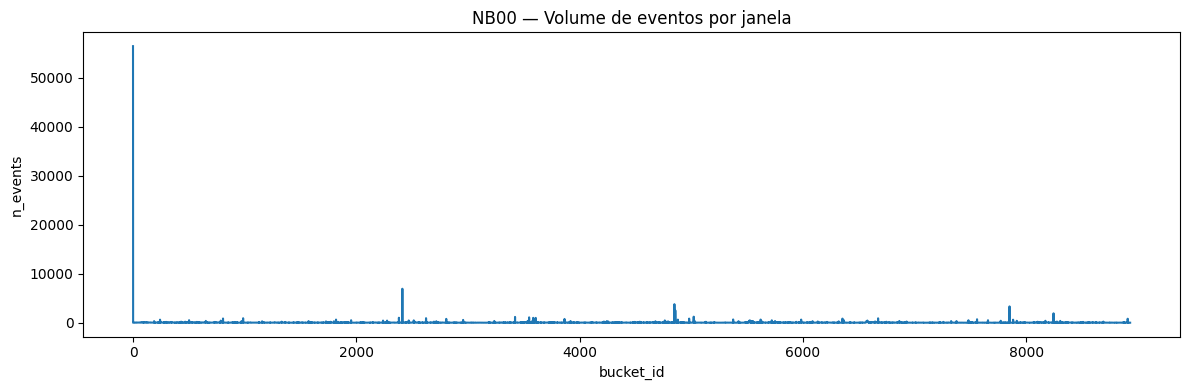

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_02_n_failed_por_janela.png


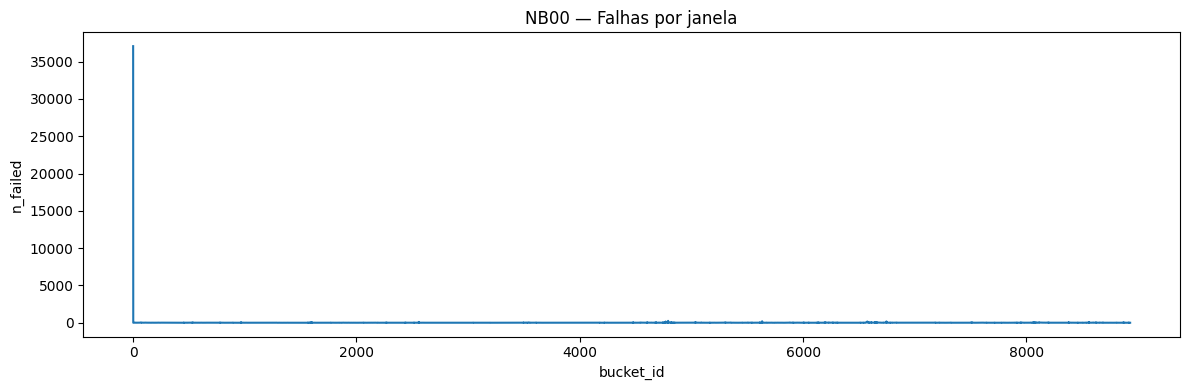

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_03_fail_rate_por_janela.png


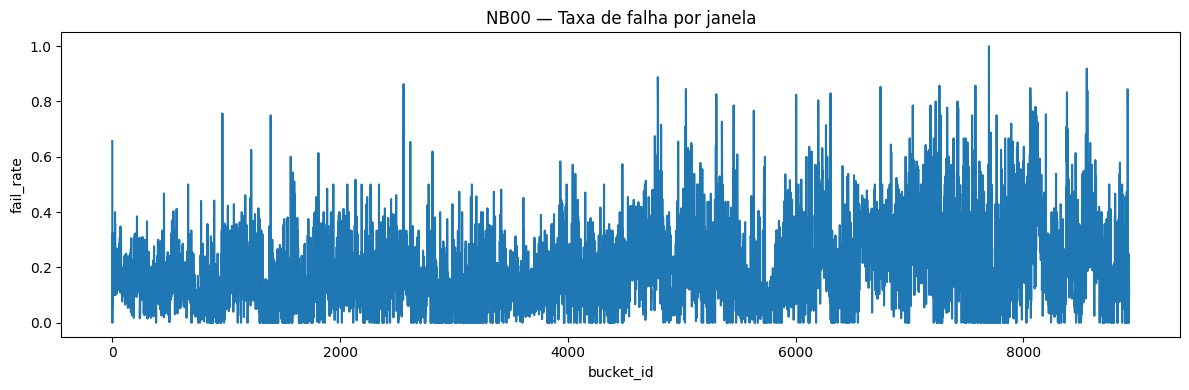

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_04_hist_fail_rate.png


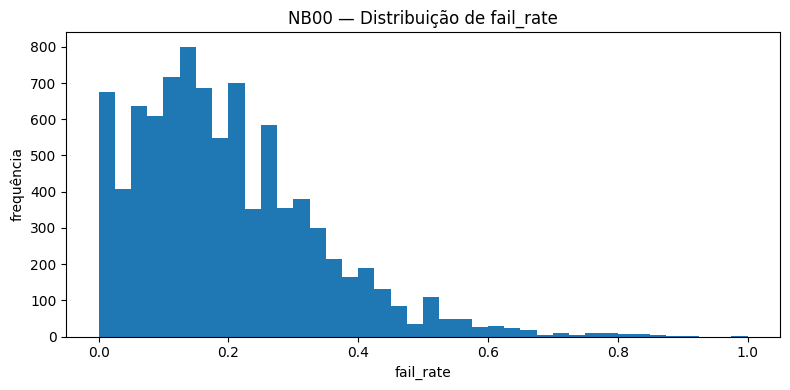


[Estatísticas de fail_rate]
mu = 0.19657957553863525
sigma = 0.14091089367866516
threshold_mu_2sigma = 0.4784013628959656
critical_windows = 390

[Resumo de episódios]


,episode_id,start_bucket,end_bucket,start_bucket_start_us,end_bucket_start_us,duration_windows,duration_minutes,max_fail_rate,mean_fail_rate,max_failed,mean_failed,sum_failed,max_events,mean_events,threshold,mu,sigma
0,1,0,0,0,0,1,5,0.656877,0.656877,37082,37082.0,37082,56452,56452.0,0.478401,0.19658,0.140911
1,2,666,666,199800000000,199800000000,1,5,0.500000,0.500000,7,7.0,7,14,14.0,0.478401,0.19658,0.140911
2,3,967,967,290100000000,290100000000,1,5,0.756757,0.756757,84,84.0,84,111,111.0,0.478401,0.19658,0.140911
3,4,1220,1220,366000000000,366000000000,1,5,0.625000,0.625000,10,10.0,10,16,16.0,0.478401,0.19658,0.140911
4,5,1391,1391,417300000000,417300000000,1,5,0.750000,0.750000,6,6.0,6,8,8.0,0.478401,0.19658,0.140911


,episodes_total,duration_windows_mean,duration_windows_median,duration_windows_max,duration_minutes_mean,duration_minutes_median,duration_minutes_max,max_fail_rate_mean,max_fail_rate_median,max_fail_rate_max,mean_fail_rate_mean,mean_fail_rate_median,mean_fail_rate_max
0,285,1.368421,1.0,7.0,6.842105,5.0,35.0,0.589036,0.5625,1.0,0.57625,0.5475,1.0


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_05_hist_duracao_episodios.png


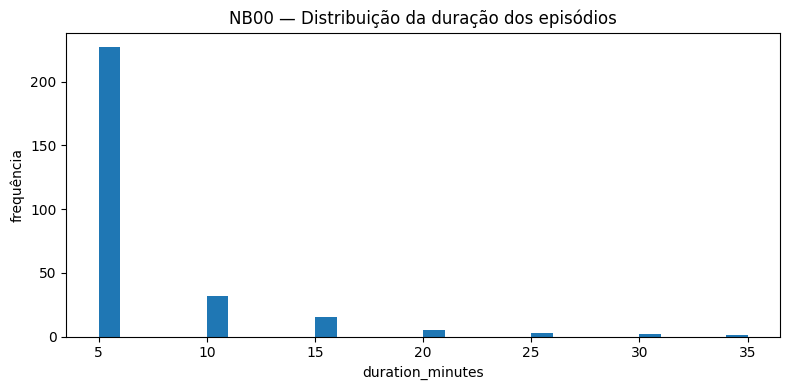

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_06_hist_max_fail_rate_episodios.png


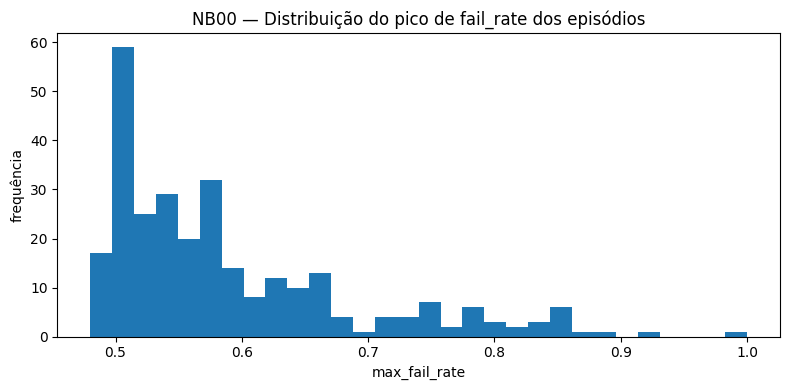


[Distribuição de estados]


,count
state,
NORMAL,5572
BEFORE,1987
AFTER,979
DURING,389


,proportion
state,
AFTER,0.109667
BEFORE,0.222583
DURING,0.043576
NORMAL,0.624174


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_07_distribuicao_estados.png


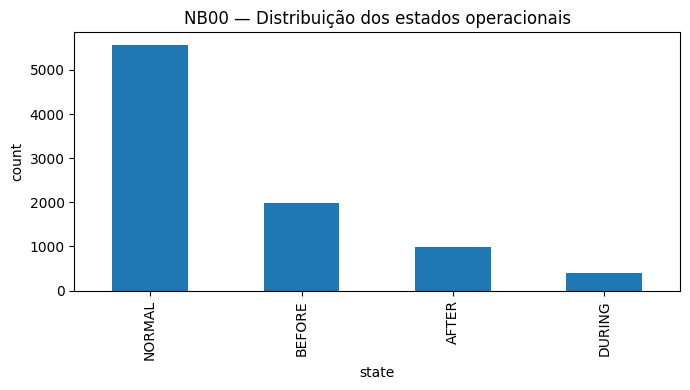


[Matriz de transição — contagens]


next_state,AFTER,BEFORE,DURING,NORMAL
state,,,,
AFTER,879,34,0,65
BEFORE,0,1703,284,0
DURING,100,184,105,0
NORMAL,0,66,0,5506



[Matriz de transição — proporções]


next_state,AFTER,BEFORE,DURING,NORMAL
state,,,,
AFTER,0.898773,0.034765,0.000000,0.066462
BEFORE,0.000000,0.857071,0.142929,0.000000
DURING,0.257069,0.473008,0.269923,0.000000
NORMAL,0.000000,0.011845,0.000000,0.988155


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_08_matriz_transicao_estados.png


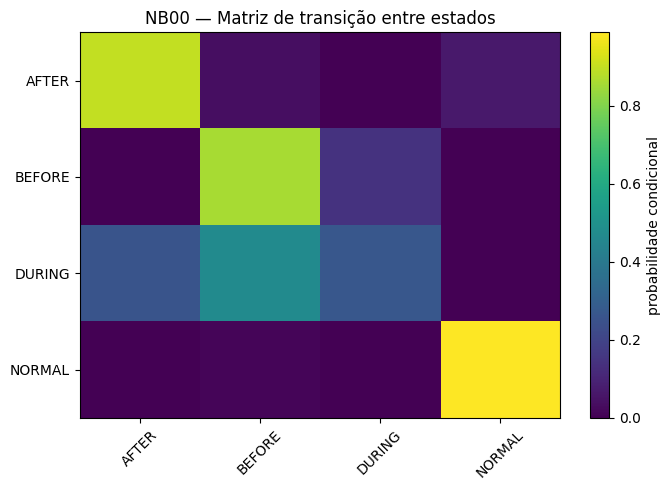


[Resumo do anticipation_supervised_dataset]
shape: (6855, 42)

[Distribuição do alvo]


,count
transition_target,
0,4868
1,1987


,proportion
transition_target,
0,0.710139
1,0.289861


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_09_distribuicao_transition_target.png


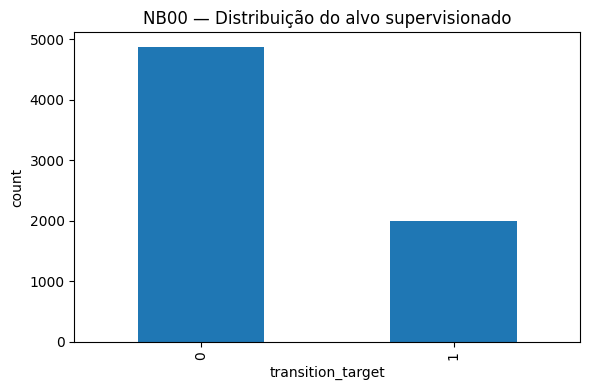


[Estado atual na base supervisionada]


,count
state,
NORMAL,4868
BEFORE,1987



[Média das features por classe]


transition_target,0,1
fail_rate,0.153959,0.230894
lag_1,0.153973,0.254571
lag_2,0.153939,0.258837
lag_3,0.154037,0.257907
rolling_mean_1h,0.154585,0.254335
rolling_std_1h,0.080245,0.123383
pct_change,0.651265,0.520457
zscore_expanding,-0.074841,0.470142
n_events,44.372021,30.660795
n_collections,16.905711,12.763966


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_fail_rate.png


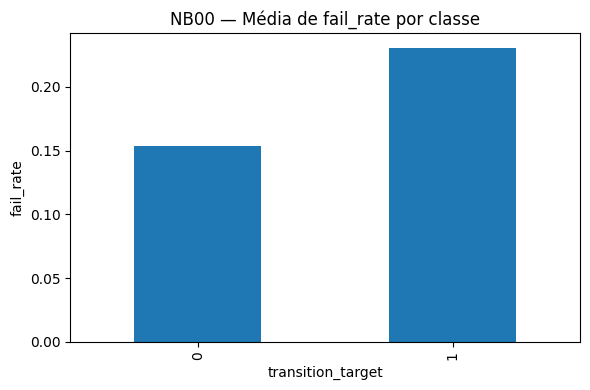

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_lag_1.png


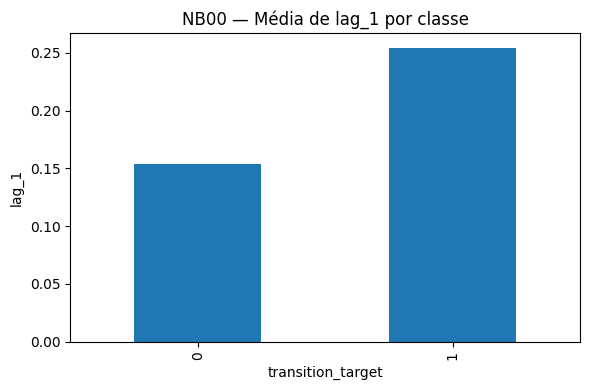

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_lag_2.png


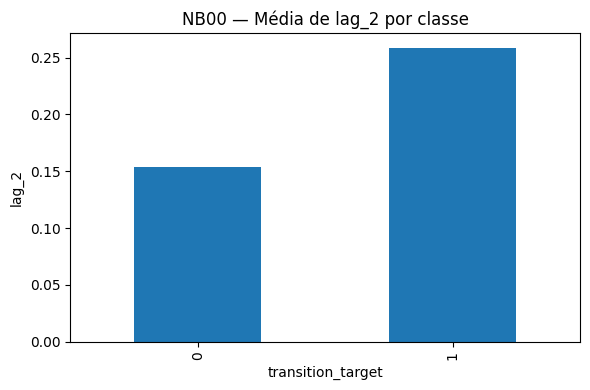

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_lag_3.png


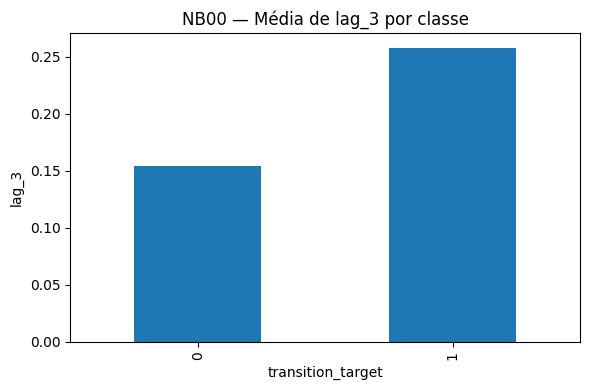

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_rolling_mean_1h.png


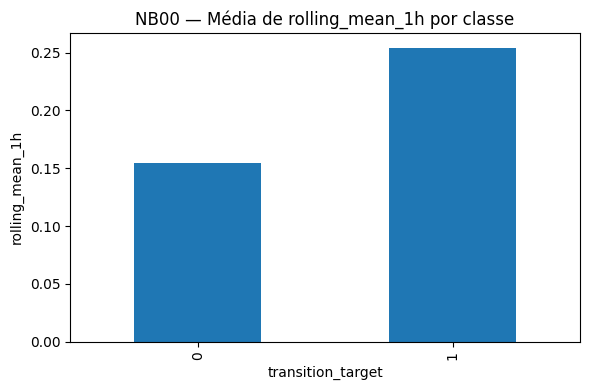

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_rolling_std_1h.png


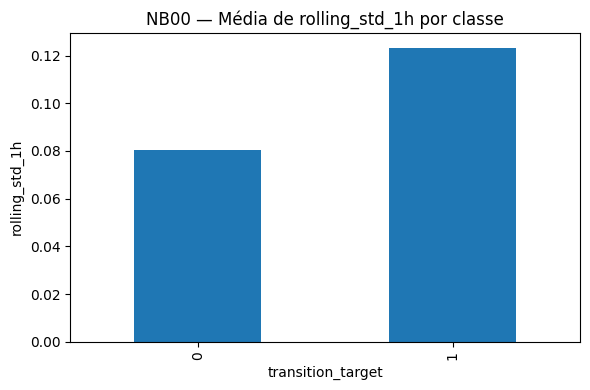

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_pct_change.png


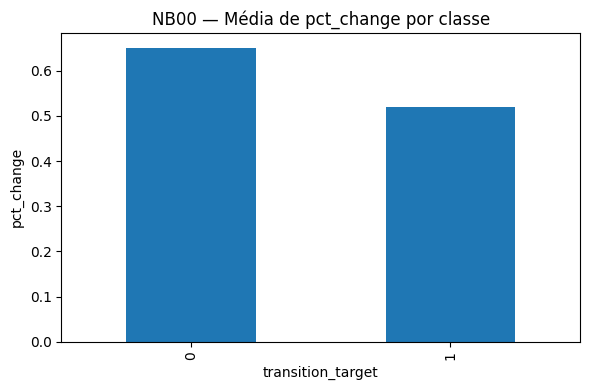

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_zscore_expanding.png


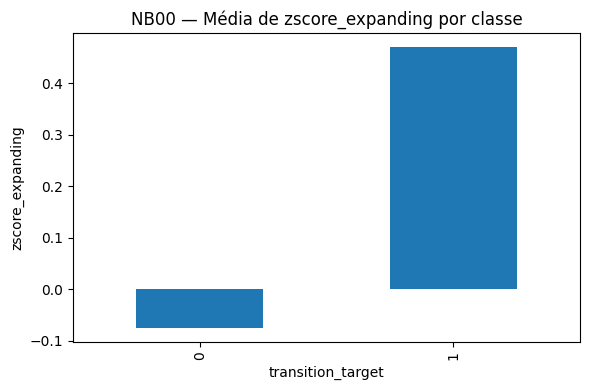

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_n_events.png


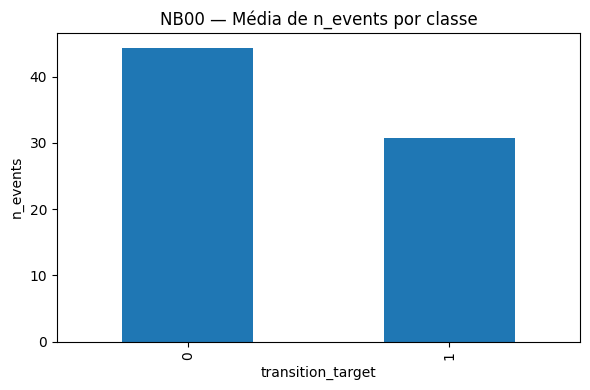

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_n_collections.png


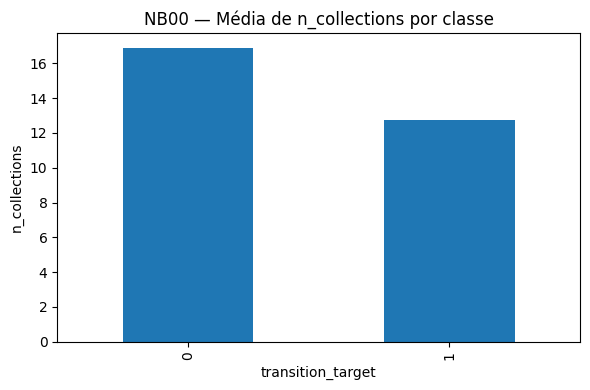

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_is_empty_window.png


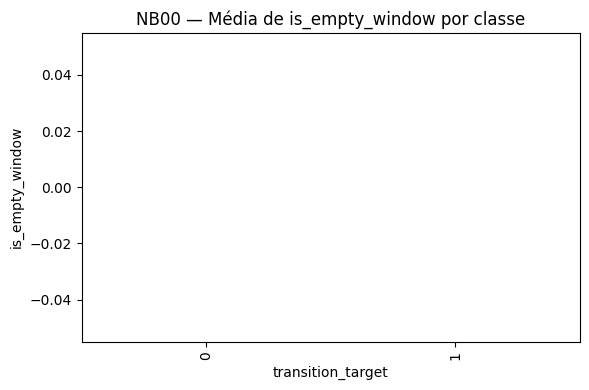


[Referências oficiais de summaries]


,nb04,nb05,nb06,nb08
0,"{'critical_windows': 390, 'episodes_detected':...","{'rows_output': 8927, 'critical_windows_output...","{'rows_labeled': 8927, 'rows_transition': 6855...","{'best_model_name': 'logreg', 'best_model_sele..."


[NB00_AED] Resumo salvo: /content/drive/MyDrive/Mestrado/04-reports/00_aed_summary.json

NB00 executado com sucesso.


In [2]:
# ============================================================
# NB00 — Análise Exploratória de Dados (AED)
# Pipeline PPCOMP_DM (Google Cluster Trace)
# Versão alinhada ao pipeline oficial revisado
# ============================================================

# -----------------------------
# 0) BOOTSTRAP
# -----------------------------
from pathlib import Path
import os
import sys
import subprocess
import importlib
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

if not Path("/content/drive/MyDrive").exists():
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("[Bootstrap] Google Drive já montado.")

REPO_DIR = Path("/content/drive/MyDrive/Mestrado/PPCOMP_DM")
GITHUB_REPO = "https://github.com/sergiocostaifes/PPCOMP_DM.git"

if not REPO_DIR.exists():
    REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["git", "clone", GITHUB_REPO, str(REPO_DIR)], check=True)
else:
    try:
        subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=True)
    except Exception as e:
        print("[Bootstrap] Aviso no git pull:", e)

os.chdir(str(REPO_DIR))

repo_str = str(REPO_DIR)
if repo_str not in sys.path:
    sys.path.insert(0, repo_str)

importlib.invalidate_caches()

from src.paths import PROCESSED_PATH, FEATURES_PATH, REPORTS_PATH, ensure_dirs
ensure_dirs()

def log(msg: str) -> None:
    print(f"[NB00_AED] {msg}")

print("PROCESSED_PATH =", PROCESSED_PATH)
print("FEATURES_PATH  =", FEATURES_PATH)
print("REPORTS_PATH   =", REPORTS_PATH)

# -----------------------------
# 1) INPUTS
# -----------------------------
CLEAN_FILE = PROCESSED_PATH / "google_trace_clean.parquet"
SERIES_FILE = FEATURES_PATH / "window_5min_series.parquet"
SERIES_SCORED_FILE = FEATURES_PATH / "window_5min_series_scored.parquet"
EPISODES_FILE = FEATURES_PATH / "episodes_detected.parquet"
FEATURES_FILE = FEATURES_PATH / "window_5min_features.parquet"
LABELED_FILE = FEATURES_PATH / "window_5min_labeled.parquet"
ANTICIPATION_FILE = FEATURES_PATH / "anticipation_supervised_dataset.parquet"
TRANSITION_FILE = FEATURES_PATH / "transition_dataset.parquet"

NB04_SUMMARY_FILE = REPORTS_PATH / "04_detect_episodes_summary.json"
NB05_SUMMARY_FILE = REPORTS_PATH / "05_feature_engineering_summary.json"
NB06_SUMMARY_FILE = REPORTS_PATH / "06_labeling_states_summary.json"
NB08_SUMMARY_FILE = REPORTS_PATH / "08_model_refinement_transition_summary.json"

def safe_read_parquet(path: Path):
    if path.exists():
        log(f"Lendo: {path}")
        return pd.read_parquet(path)
    log(f"Arquivo não encontrado: {path}")
    return None

def safe_read_json(path: Path):
    if path.exists():
        log(f"Lendo summary: {path}")
        return json.loads(path.read_text(encoding="utf-8"))
    log(f"Summary não encontrado: {path}")
    return None

df_clean = safe_read_parquet(CLEAN_FILE)
df_series = safe_read_parquet(SERIES_FILE)
df_series_scored = safe_read_parquet(SERIES_SCORED_FILE)
df_episodes = safe_read_parquet(EPISODES_FILE)
df_features = safe_read_parquet(FEATURES_FILE)
df_labeled = safe_read_parquet(LABELED_FILE)

if ANTICIPATION_FILE.exists():
    df_supervised = safe_read_parquet(ANTICIPATION_FILE)
    supervised_name = "anticipation_supervised_dataset"
else:
    df_supervised = safe_read_parquet(TRANSITION_FILE)
    supervised_name = "transition_dataset"

summary_nb04 = safe_read_json(NB04_SUMMARY_FILE)
summary_nb05 = safe_read_json(NB05_SUMMARY_FILE)
summary_nb06 = safe_read_json(NB06_SUMMARY_FILE)
summary_nb08 = safe_read_json(NB08_SUMMARY_FILE)

# -----------------------------
# 2) FUNÇÕES AUXILIARES
# -----------------------------
FIG_DIR = REPORTS_PATH / "figures_nb00_aed"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_current_fig(name: str):
    out = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=150, bbox_inches="tight")
    log(f"Figura salva: {out}")

def show_basic_info(df: pd.DataFrame, name: str):
    if df is None:
        return
    print(f"\n===== {name} =====")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    display(df.head())

def maybe_to_int_dict(d: dict):
    return {str(k): int(v) for k, v in d.items()}

# -----------------------------
# 3) AED DO DADO DE ORIGEM OPERACIONAL (CLEAN)
# -----------------------------
clean_summary = {}

if df_clean is not None:
    print("\n===== google_trace_clean =====")
    print("shape:", df_clean.shape)
    print("columns:", list(df_clean.columns))
    display(df_clean.head())

    required_clean_cols = {"time", "event", "failed", "t_rel_us", "hour"}
    missing_clean = required_clean_cols - set(df_clean.columns)
    assert not missing_clean, f"Colunas ausentes em google_trace_clean: {missing_clean}"

    # Sumário básico
    clean_summary = {
        "rows": int(len(df_clean)),
        "cols": int(df_clean.shape[1]),
        "time_min": int(df_clean["time"].min()),
        "time_max": int(df_clean["time"].max()),
        "t_rel_us_min": int(df_clean["t_rel_us"].min()),
        "t_rel_us_max": int(df_clean["t_rel_us"].max()),
        "hour_min": int(df_clean["hour"].min()),
        "hour_max": int(df_clean["hour"].max()),
        "n_unique_machine_id": int(df_clean["machine_id"].nunique()) if "machine_id" in df_clean.columns else None,
        "n_unique_collection_id": int(df_clean["collection_id"].nunique()) if "collection_id" in df_clean.columns else None,
        "resource_request_presence_rate": float(df_clean["resource_request"].notna().mean()) if "resource_request" in df_clean.columns else None,
    }

    hour0_mask = df_clean["hour"] == 0
    clean_summary["rows_hour0"] = int(hour0_mask.sum())
    clean_summary["pct_hour0"] = float(hour0_mask.mean())
    clean_summary["failed_sum_hour0"] = int(df_clean.loc[hour0_mask, "failed"].sum())

    print("\n[Resumo básico do dado de origem clean]")
    display(pd.DataFrame([clean_summary]))

    # Distribuição de eventos
    event_counts = df_clean["event"].value_counts(dropna=False)
    print("\n[Distribuição de event]")
    display(event_counts.to_frame("count"))

    plt.figure(figsize=(8, 4))
    event_counts.plot(kind="bar")
    plt.xlabel("event")
    plt.ylabel("count")
    plt.title("NB00 — Distribuição de eventos no dado de origem clean")
    save_current_fig("fig_00_event_distribution.png")
    plt.show()

    clean_summary["event_distribution"] = maybe_to_int_dict(event_counts.to_dict())

    # Distribuição de failed
    failed_counts = df_clean["failed"].value_counts(dropna=False).sort_index()
    print("\n[Distribuição de failed]")
    display(failed_counts.to_frame("count"))

    plt.figure(figsize=(6, 4))
    failed_counts.plot(kind="bar")
    plt.xlabel("failed")
    plt.ylabel("count")
    plt.title("NB00 — Distribuição de failed no dado de origem clean")
    save_current_fig("fig_00_failed_distribution.png")
    plt.show()

    clean_summary["failed_distribution"] = maybe_to_int_dict(failed_counts.to_dict())

    # scheduling_class
    if "scheduling_class" in df_clean.columns:
        sched_counts = df_clean["scheduling_class"].value_counts(dropna=False).sort_index()
        print("\n[Distribuição de scheduling_class]")
        display(sched_counts.to_frame("count"))

        plt.figure(figsize=(6, 4))
        sched_counts.plot(kind="bar")
        plt.xlabel("scheduling_class")
        plt.ylabel("count")
        plt.title("NB00 — Distribuição de scheduling_class")
        save_current_fig("fig_00_scheduling_class_distribution.png")
        plt.show()

        clean_summary["scheduling_class_distribution"] = maybe_to_int_dict(sched_counts.to_dict())

    # priority
    if "priority" in df_clean.columns:
        priority_stats = {
            "priority_mean": float(df_clean["priority"].mean()),
            "priority_median": float(df_clean["priority"].median()),
            "priority_std": float(df_clean["priority"].std(ddof=0)),
            "priority_min": float(df_clean["priority"].min()),
            "priority_max": float(df_clean["priority"].max()),
        }
        clean_summary.update(priority_stats)

        print("\n[Estatísticas de priority]")
        display(pd.DataFrame([priority_stats]))

        plt.figure(figsize=(8, 4))
        plt.hist(df_clean["priority"], bins=40)
        plt.xlabel("priority")
        plt.ylabel("frequência")
        plt.title("NB00 — Distribuição de priority")
        save_current_fig("fig_00_priority_hist.png")
        plt.show()

    # Cobertura temporal por hour
    hourly_volume = df_clean.groupby("hour").size()
    print("\n[Volume de registros por hour]")
    display(hourly_volume.head(20).to_frame("count"))

    plt.figure(figsize=(12, 4))
    plt.plot(hourly_volume.index, hourly_volume.values)
    plt.xlabel("hour")
    plt.ylabel("count")
    plt.title("NB00 — Volume de registros por hour")
    save_current_fig("fig_00_hour_distribution.png")
    plt.show()

    clean_summary["hourly_volume_min"] = int(hourly_volume.min())
    clean_summary["hourly_volume_max"] = int(hourly_volume.max())
    clean_summary["hourly_volume_mean"] = float(hourly_volume.mean())

    # Hour 0
    hour0_event_counts = df_clean.loc[hour0_mask, "event"].value_counts(dropna=False)
    print("\n[Distribuição de event em hour == 0]")
    display(hour0_event_counts.to_frame("count"))

    clean_summary["hour0_event_distribution"] = maybe_to_int_dict(hour0_event_counts.to_dict())

# -----------------------------
# 4) VISÃO GERAL DOS ARTEFATOS DO PIPELINE
# -----------------------------
show_basic_info(df_series, "window_5min_series")
show_basic_info(df_series_scored, "window_5min_series_scored")
show_basic_info(df_episodes, "episodes_detected")
show_basic_info(df_features, "window_5min_features")
show_basic_info(df_labeled, "window_5min_labeled")
show_basic_info(df_supervised, supervised_name)

# -----------------------------
# 5) TABELA-SÍNTESE DOS ARTEFATOS
# -----------------------------
artifact_rows = []
for name, df in [
    ("google_trace_clean", df_clean),
    ("window_5min_series", df_series),
    ("window_5min_series_scored", df_series_scored),
    ("episodes_detected", df_episodes),
    ("window_5min_features", df_features),
    ("window_5min_labeled", df_labeled),
    (supervised_name, df_supervised),
]:
    if df is not None:
        artifact_rows.append({
            "artifact": name,
            "rows": int(df.shape[0]),
            "cols": int(df.shape[1]),
        })

artifacts_summary = pd.DataFrame(artifact_rows)
print("\n[Resumo dos artefatos]")
display(artifacts_summary)

# -----------------------------
# 6) ANÁLISE DA SÉRIE TEMPORAL
# -----------------------------
series_ref = df_series_scored if df_series_scored is not None else df_series

mu_fail_rate = None
sigma_fail_rate = None
threshold_fail_rate = None
critical_windows = None

if series_ref is not None:
    assert "bucket_id" in series_ref.columns, "bucket_id ausente na série"
    assert "n_events" in series_ref.columns, "n_events ausente na série"
    assert "n_failed" in series_ref.columns, "n_failed ausente na série"

    series_ref = series_ref.copy().sort_values("bucket_id").reset_index(drop=True)

    if "fail_rate" not in series_ref.columns:
        series_ref["fail_rate"] = np.where(
            series_ref["n_events"] > 0,
            series_ref["n_failed"] / series_ref["n_events"],
            0.0
        )

    if "is_critical" not in series_ref.columns:
        mu_tmp = float(series_ref["fail_rate"].mean())
        sigma_tmp = float(series_ref["fail_rate"].std(ddof=0))
        thr_tmp = float(mu_tmp + 2 * sigma_tmp)
        series_ref["is_critical"] = (series_ref["fail_rate"] >= thr_tmp).astype(int)

    plt.figure(figsize=(12, 4))
    plt.plot(series_ref["bucket_id"], series_ref["n_events"])
    plt.xlabel("bucket_id")
    plt.ylabel("n_events")
    plt.title("NB00 — Volume de eventos por janela")
    save_current_fig("fig_01_n_events_por_janela.png")
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(series_ref["bucket_id"], series_ref["n_failed"])
    plt.xlabel("bucket_id")
    plt.ylabel("n_failed")
    plt.title("NB00 — Falhas por janela")
    save_current_fig("fig_02_n_failed_por_janela.png")
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(series_ref["bucket_id"], series_ref["fail_rate"])
    plt.xlabel("bucket_id")
    plt.ylabel("fail_rate")
    plt.title("NB00 — Taxa de falha por janela")
    save_current_fig("fig_03_fail_rate_por_janela.png")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(series_ref["fail_rate"], bins=40)
    plt.xlabel("fail_rate")
    plt.ylabel("frequência")
    plt.title("NB00 — Distribuição de fail_rate")
    save_current_fig("fig_04_hist_fail_rate.png")
    plt.show()

    mu_fail_rate = float(series_ref["fail_rate"].mean())
    sigma_fail_rate = float(series_ref["fail_rate"].std(ddof=0))
    threshold_fail_rate = float(mu_fail_rate + 2 * sigma_fail_rate)
    critical_windows = int(series_ref["is_critical"].sum())

    print("\n[Estatísticas de fail_rate]")
    print("mu =", mu_fail_rate)
    print("sigma =", sigma_fail_rate)
    print("threshold_mu_2sigma =", threshold_fail_rate)
    print("critical_windows =", critical_windows)

# -----------------------------
# 7) ANÁLISE DOS EPISÓDIOS
# -----------------------------
episode_summary = {}

if df_episodes is not None:
    print("\n[Resumo de episódios]")
    display(df_episodes.head())

    episode_summary = {
        "episodes_total": int(len(df_episodes)),
    }

    for col in [
        "duration_windows",
        "duration_minutes",
        "max_fail_rate",
        "mean_fail_rate",
    ]:
        if col in df_episodes.columns:
            episode_summary[f"{col}_mean"] = float(df_episodes[col].mean())
            episode_summary[f"{col}_median"] = float(df_episodes[col].median())
            episode_summary[f"{col}_max"] = float(df_episodes[col].max())

    display(pd.DataFrame([episode_summary]))

    if "duration_minutes" in df_episodes.columns:
        plt.figure(figsize=(8, 4))
        plt.hist(df_episodes["duration_minutes"], bins=30)
        plt.xlabel("duration_minutes")
        plt.ylabel("frequência")
        plt.title("NB00 — Distribuição da duração dos episódios")
        save_current_fig("fig_05_hist_duracao_episodios.png")
        plt.show()

    if "max_fail_rate" in df_episodes.columns:
        plt.figure(figsize=(8, 4))
        plt.hist(df_episodes["max_fail_rate"], bins=30)
        plt.xlabel("max_fail_rate")
        plt.ylabel("frequência")
        plt.title("NB00 — Distribuição do pico de fail_rate dos episódios")
        save_current_fig("fig_06_hist_max_fail_rate_episodios.png")
        plt.show()

# -----------------------------
# 8) ANÁLISE DOS ESTADOS
# -----------------------------
state_counts = None
state_props = None
transition_counts = None
transition_probs = None

if df_labeled is not None:
    assert "state" in df_labeled.columns, "state ausente em window_5min_labeled"

    state_counts = df_labeled["state"].value_counts()
    state_props = df_labeled["state"].value_counts(normalize=True).sort_index()

    print("\n[Distribuição de estados]")
    display(state_counts.to_frame("count"))
    display(state_props.to_frame("proportion"))

    plt.figure(figsize=(7, 4))
    state_counts.plot(kind="bar")
    plt.xlabel("state")
    plt.ylabel("count")
    plt.title("NB00 — Distribuição dos estados operacionais")
    save_current_fig("fig_07_distribuicao_estados.png")
    plt.show()

    if "next_state" in df_labeled.columns:
        transition_counts = (
            df_labeled.dropna(subset=["next_state"])
            .groupby(["state", "next_state"])
            .size()
            .unstack(fill_value=0)
        )

        print("\n[Matriz de transição — contagens]")
        display(transition_counts)

        transition_probs = transition_counts.div(
            transition_counts.sum(axis=1), axis=0
        )

        print("\n[Matriz de transição — proporções]")
        display(transition_probs)

        plt.figure(figsize=(7, 5))
        plt.imshow(transition_probs.values, aspect="auto")
        plt.xticks(
            range(len(transition_probs.columns)),
            transition_probs.columns,
            rotation=45
        )
        plt.yticks(range(len(transition_probs.index)), transition_probs.index)
        plt.colorbar(label="probabilidade condicional")
        plt.title("NB00 — Matriz de transição entre estados")
        save_current_fig("fig_08_matriz_transicao_estados.png")
        plt.show()

# -----------------------------
# 9) ANÁLISE DA BASE SUPERVISIONADA
# -----------------------------
target_counts = None
target_props = None
current_state_counts = None
grouped_stats = None

if df_supervised is not None:
    print(f"\n[Resumo do {supervised_name}]")
    print("shape:", df_supervised.shape)

    if "transition_target" in df_supervised.columns:
        target_counts = df_supervised["transition_target"].value_counts().sort_index()
        target_props = df_supervised["transition_target"].value_counts(normalize=True).sort_index()

        print("\n[Distribuição do alvo]")
        display(target_counts.to_frame("count"))
        display(target_props.to_frame("proportion"))

        plt.figure(figsize=(6, 4))
        target_counts.plot(kind="bar")
        plt.xlabel("transition_target")
        plt.ylabel("count")
        plt.title("NB00 — Distribuição do alvo supervisionado")
        save_current_fig("fig_09_distribuicao_transition_target.png")
        plt.show()

    if "state" in df_supervised.columns:
        current_state_counts = df_supervised["state"].value_counts()

        print("\n[Estado atual na base supervisionada]")
        display(current_state_counts.to_frame("count"))

    candidate_features = [
        "fail_rate",
        "lag_1",
        "lag_2",
        "lag_3",
        "rolling_mean_1h",
        "rolling_std_1h",
        "pct_change",
        "zscore_expanding",
        "n_events",
        "n_collections",
        "is_empty_window",
    ]

    available_features = [c for c in candidate_features if c in df_supervised.columns]

    if "transition_target" in df_supervised.columns and available_features:
        grouped_stats = (
            df_supervised.groupby("transition_target")[available_features]
            .mean()
            .T
        )

        print("\n[Média das features por classe]")
        display(grouped_stats)

        for feature in available_features:
            plt.figure(figsize=(6, 4))
            means = df_supervised.groupby("transition_target")[feature].mean()
            means.plot(kind="bar")
            plt.xlabel("transition_target")
            plt.ylabel(feature)
            plt.title(f"NB00 — Média de {feature} por classe")
            fname = f"fig_feature_mean_{feature}.png".replace("/", "_")
            save_current_fig(fname)
            plt.show()

# -----------------------------
# 10) VALIDAÇÃO COM SUMMARIES OFICIAIS
# -----------------------------
official_checks = {}

if summary_nb04 is not None:
    official_checks["nb04"] = {
        "critical_windows": summary_nb04.get("critical_windows"),
        "episodes_detected": summary_nb04.get("episodes_detected"),
    }

if summary_nb05 is not None:
    official_checks["nb05"] = {
        "rows_output": summary_nb05.get("rows_output"),
        "critical_windows_output": summary_nb05.get("critical_windows_output"),
    }

if summary_nb06 is not None:
    official_checks["nb06"] = {
        "rows_labeled": summary_nb06.get("rows_labeled"),
        "rows_transition": summary_nb06.get("rows_transition"),
        "states_distribution": summary_nb06.get("states_distribution"),
        "transition_target_distribution": summary_nb06.get("transition_target_distribution"),
    }

if summary_nb08 is not None:
    official_checks["nb08"] = {
        "best_model_name": summary_nb08.get("best_model_name"),
        "best_model_selection_metric": summary_nb08.get("best_model_selection_metric"),
        "best_model_selection_value": summary_nb08.get("best_model_selection_value"),
    }

print("\n[Referências oficiais de summaries]")
display(pd.DataFrame([official_checks]))

# -----------------------------
# 11) SUMMARY JSON
# -----------------------------
summary = {
    "artifacts_available": {
        "google_trace_clean": bool(df_clean is not None),
        "window_5min_series": bool(df_series is not None),
        "window_5min_series_scored": bool(df_series_scored is not None),
        "episodes_detected": bool(df_episodes is not None),
        "window_5min_features": bool(df_features is not None),
        "window_5min_labeled": bool(df_labeled is not None),
        "anticipation_supervised_dataset": bool(
            ANTICIPATION_FILE.exists() and df_supervised is not None
        ),
        "transition_dataset_legacy": bool(
            (not ANTICIPATION_FILE.exists()) and (df_supervised is not None)
        ),
    },
    "artifacts_summary": artifacts_summary.to_dict("records"),
    "supervised_dataset_name_used": supervised_name,
    "official_checks": official_checks,
}

if clean_summary:
    summary["clean_source"] = clean_summary

if series_ref is not None and "fail_rate" in series_ref.columns:
    summary["series"] = {
        "rows": int(len(series_ref)),
        "mu_fail_rate": float(mu_fail_rate),
        "sigma_fail_rate": float(sigma_fail_rate),
        "threshold_mu_2sigma": float(threshold_fail_rate),
        "critical_windows": int(critical_windows),
    }

if df_episodes is not None:
    summary["episodes"] = {
        "rows": int(len(df_episodes)),
    }
    for col in [
        "duration_windows",
        "duration_minutes",
        "max_fail_rate",
        "mean_fail_rate",
    ]:
        if col in df_episodes.columns:
            summary["episodes"][f"{col}_mean"] = float(df_episodes[col].mean())
            summary["episodes"][f"{col}_median"] = float(df_episodes[col].median())
            summary["episodes"][f"{col}_max"] = float(df_episodes[col].max())

if df_labeled is not None and "state" in df_labeled.columns:
    summary["labeled"] = {
        "rows": int(len(df_labeled)),
        "state_distribution": maybe_to_int_dict(
            df_labeled["state"].value_counts().to_dict()
        )
    }

if transition_probs is not None:
    summary["state_transition_matrix"] = {
        "rows": list(transition_probs.index),
        "cols": list(transition_probs.columns),
        "values": transition_probs.round(6).values.tolist(),
    }

if df_supervised is not None and "transition_target" in df_supervised.columns:
    summary["supervised_dataset"] = {
        "rows": int(len(df_supervised)),
        "cols": int(df_supervised.shape[1]),
        "target_distribution": {
            str(k): int(v)
            for k, v in df_supervised["transition_target"].value_counts().sort_index().to_dict().items()
        },
    }

    if "state" in df_supervised.columns:
        summary["supervised_dataset"]["current_state_distribution"] = maybe_to_int_dict(
            df_supervised["state"].value_counts().to_dict()
        )

if grouped_stats is not None:
    summary["supervised_feature_means_by_class"] = grouped_stats.round(6).to_dict()

summary_file = REPORTS_PATH / "00_aed_summary.json"
summary_file.write_text(
    json.dumps(summary, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

log(f"Resumo salvo: {summary_file}")

print("\nNB00 executado com sucesso.")

## 8. Conclusão da Análise Exploratória de Dados

A análise exploratória foi concluída com sucesso e confirmou que o pipeline oficial
revisado apresenta consistência estrutural entre o dado de origem operacional disponível
e os artefatos derivados utilizados nas etapas posteriores.

Nesta execução, o notebook carregou e analisou os seguintes artefatos:
- `google_trace_clean.parquet`
- `window_5min_series.parquet`
- `window_5min_series_scored.parquet`
- `episodes_detected.parquet`
- `window_5min_features.parquet`
- `window_5min_labeled.parquet`
- `anticipation_supervised_dataset.parquet`

Além disso, o NB00 também recuperou os summaries oficiais de:
- NB04
- NB05
- NB06
- NB08

Isso permitiu realizar a AED já alinhada à versão oficial do pipeline, sem reaproveitar
números ou estruturas antigas.

## 9. Achados Exploratórios da Execução Atual

### 9.1 Estrutura geral dos artefatos

A tabela-síntese dos artefatos mostrou a seguinte estrutura:

- `google_trace_clean`: 405891 linhas e 23 colunas
- `window_5min_series`: 8930 linhas e 18 colunas
- `window_5min_series_scored`: 8930 linhas e 20 colunas
- `episodes_detected`: 285 linhas e 17 colunas
- `window_5min_features`: 8927 linhas e 28 colunas
- `window_5min_labeled`: 8927 linhas e 39 colunas
- `anticipation_supervised_dataset`: 6855 linhas e 42 colunas

Esses números mostram claramente a progressão do pipeline:
- a série contínua preserva o eixo temporal completo;
- a base de features sofre apenas o trim mínimo devido aos lags;
- a base supervisionada final reduz o universo de janelas para os casos elegíveis na
  formulação de antecipação.

### 9.2 Caracterização do dado de origem operacional (clean)

A AED do dado de origem foi realizada sobre `google_trace_clean.parquet`, que representa
a base de eventos já limpa e normalizada que alimenta o restante do pipeline.

Os principais indicadores observados foram:
- `rows = 405891`
- `cols = 23`
- `time_min = 0`
- `time_max = 2678923967375`
- `t_rel_us_min = 0`
- `t_rel_us_max = 2678923967375`
- `hour_min = 0`
- `hour_max = 744`
- `n_unique_machine_id = 96174`
- `n_unique_collection_id = 4057`
- `resource_request_presence_rate = 0.9980930841038604`

Esses números mostram que a base clean preserva grande diversidade de máquinas e coleções,
além de elevada disponibilidade da informação de `resource_request`, o que sustenta a
engenharia posterior de atributos baseados em CPU e memória solicitadas.

### 9.3 Distribuição de eventos no dado de origem

A distribuição de `event` foi a seguinte:

- `FINISH = 92864`
- `FAIL = 92678`
- `ENABLE = 75907`
- `SCHEDULE = 69104`
- `LOST = 59515`
- `EVICT = 14756`
- `KILL = 951`
- `UPDATE_PENDING = 111`
- `QUEUE = 4`
- `UPDATE_RUNNING = 1`

Essa distribuição mostra que a base é dominada por poucos tipos de evento relevantes,
com presença muito pequena de eventos raros.

Do ponto de vista exploratório, isso sugere:
- predominância de um núcleo operacional relativamente bem definido;
- forte presença de `FAIL`, coerente com o foco do trabalho em criticidade;
- cauda de eventos raros que, embora pouco frequentes, pode contribuir para caracterização
  de comportamento anômalo em etapas posteriores.

### 9.4 Distribuição de falhas, scheduling class e priority

Na coluna `failed`, a base apresentou:
- `0 = 313213`
- `1 = 92678`

Em `scheduling_class`, a distribuição foi:
- classe `0 = 120414`
- classe `1 = 105329`
- classe `2 = 131567`
- classe `3 = 48581`

As estatísticas de `priority` foram:
- `priority_mean = 147.91340778681962`
- `priority_median = 105.0`
- `priority_std = 116.65683405827747`
- `priority_min = 0.0`
- `priority_max = 450.0`

Exploratoriamente, esses resultados indicam:
- presença importante de registros marcados como falha;
- heterogeneidade razoável entre classes de escalonamento;
- distribuição ampla de prioridade, com variabilidade elevada.

Isso reforça a leitura de que o dado de origem não é homogêneo e contém múltiplas
dimensões operacionais potencialmente informativas.

### 9.5 Cobertura temporal e comportamento de `hour == 0`

A análise temporal do dado de origem mostrou:
- `rows_hour0 = 56740`
- `pct_hour0 = 0.13979122473767588`
- `failed_sum_hour0 = 37150`

Além disso:
- `hourly_volume_min = 26`
- `hourly_volume_max = 56740`
- `hourly_volume_mean = 544.820134228188`

A distribuição de eventos em `hour == 0` foi:
- `FAIL = 37150`
- `ENABLE = 18682`
- `FINISH = 666`
- `SCHEDULE = 161`
- `LOST = 78`
- `KILL = 3`

Esses números mostram que a primeira hora da série não é apenas volumosa, mas também
fortemente marcada por falhas e eventos de habilitação.

Essa observação é metodologicamente importante porque:
- justifica a atenção dada à preservação de `hour == 0` no pipeline revisado;
- ajuda a explicar a dominância do bucket inicial na série agregada;
- mostra que o início da série deve ser tratado como característica empírica relevante,
  e não descartado automaticamente como ruído.

### 9.6 Comportamento da taxa de falha na série agregada

A AED foi realizada com base em `window_5min_series_scored`, que já contém a taxa de
falha e a marcação de criticidade oficial.

As estatísticas observadas foram:
- `mu_fail_rate = 0.19657957553863525`
- `sigma_fail_rate = 0.14091089367866516`
- `threshold_mu_2sigma = 0.4784013628959656`
- `critical_windows = 390`

Esses valores coincidem com a referência oficial do NB04.

A leitura exploratória da série indica:
- concentração maior de janelas em níveis baixos e intermediários de `fail_rate`;
- presença de cauda à direita;
- existência de picos de criticidade bem destacados, inclusive no início da série.

Em termos exploratórios, isso sugere que a métrica `fail_rate` é adequada para distinguir
regimes mais estáveis de janelas com degradação operacional relevante.

### 9.7 Episódios críticos

A análise dos episódios detectados mostrou:
- `episodes_total = 285`
- `duration_windows_mean = 1.368421052631579`
- `duration_windows_median = 1.0`
- `duration_windows_max = 7.0`
- `duration_minutes_mean = 6.842105263157895`
- `duration_minutes_median = 5.0`
- `duration_minutes_max = 35.0`

Também foram observados:
- `max_fail_rate_mean = 0.5890361433489281`
- `max_fail_rate_median = 0.5625`
- `max_fail_rate_max = 1.0`
- `mean_fail_rate_mean = 0.5762500081145973`
- `mean_fail_rate_median = 0.5475000143051147`
- `mean_fail_rate_max = 1.0`

Esses resultados reforçam um padrão importante do problema:
- a maioria dos episódios é curta;
- a duração mediana é de apenas uma janela;
- ainda assim, os picos de criticidade podem ser bastante intensos.

Isso favorece a interpretação de que o problema exige sensibilidade temporal para detectar
mudanças rápidas, e não apenas tendência lenta de longo prazo.

### 9.8 Estados operacionais

A base rotulada apresentou:
- `NORMAL = 5572`
- `BEFORE = 1987`
- `AFTER = 979`
- `DURING = 389`

Em proporção:
- `NORMAL = 0.624174`
- `BEFORE = 0.222583`
- `AFTER = 0.109667`
- `DURING = 0.043576`

Essa distribuição confirma que:
- o sistema opera majoritariamente em regime normal;
- há quantidade expressiva de janelas `BEFORE`;
- as janelas `DURING` são relativamente raras, mas não desprezíveis.

Do ponto de vista exploratório, isso sustenta a formulação do problema como antecipação de
criticidade, já que existe massa suficiente de janelas anteriores ao evento para análise
supervisionada.

### 9.9 Dinâmica de transição entre estados

A matriz de transição entre estados mostrou as seguintes probabilidades condicionais:

- `AFTER -> AFTER = 0.898773`
- `AFTER -> BEFORE = 0.034765`
- `AFTER -> NORMAL = 0.066462`

- `BEFORE -> BEFORE = 0.857071`
- `BEFORE -> DURING = 0.142929`

- `DURING -> AFTER = 0.257069`
- `DURING -> BEFORE = 0.473008`
- `DURING -> DURING = 0.269923`

- `NORMAL -> BEFORE = 0.011845`
- `NORMAL -> NORMAL = 0.988155`

Esses valores sugerem alguns padrões importantes:
- `NORMAL` é altamente persistente;
- `BEFORE` também apresenta persistência elevada, mas já contém uma probabilidade
  relevante de entrada em `DURING`;
- `DURING` é mais dinâmico, com redistribuição para `AFTER`, `BEFORE` e permanência
  parcial no próprio estado.

Essa matriz fortalece a leitura de que o estado `BEFORE` não é apenas uma construção
artificial, mas uma região temporal que de fato antecede parte das entradas em criticidade.

### 9.10 Estrutura da base supervisionada de antecipação

A base supervisionada utilizada nesta AED foi:
- `anticipation_supervised_dataset`
- `rows = 6855`
- `cols = 42`

Distribuição do alvo:
- classe `0`: 4868
- classe `1`: 1987

Em proporção:
- classe `0`: 0.710139
- classe `1`: 0.289861

Distribuição do estado atual:
- `NORMAL = 4868`
- `BEFORE = 1987`

Esses números mostram que a formulação final do problema:
- trabalha apenas com janelas elegíveis em `NORMAL` e `BEFORE`;
- produz uma base com desbalanceamento moderado, e não extremo;
- preserva volume suficiente de casos positivos para modelagem supervisionada.

### 9.11 Diferenças exploratórias entre as classes supervisionadas

As médias das features por classe mostraram diferenças claras entre os grupos.

Para a classe `0`:
- `fail_rate = 0.153959`
- `lag_1 = 0.153973`
- `lag_2 = 0.153939`
- `lag_3 = 0.154037`
- `rolling_mean_1h = 0.154585`
- `rolling_std_1h = 0.080245`
- `pct_change = 0.651265`
- `zscore_expanding = -0.074841`
- `n_events = 44.372021`
- `n_collections = 16.905711`

Para a classe `1`:
- `fail_rate = 0.230894`
- `lag_1 = 0.254571`
- `lag_2 = 0.258837`
- `lag_3 = 0.257907`
- `rolling_mean_1h = 0.254335`
- `rolling_std_1h = 0.123383`
- `pct_change = 0.520457`
- `zscore_expanding = 0.470142`
- `n_events = 30.660795`
- `n_collections = 12.763966`

Exploratoriamente, isso indica que as janelas que antecedem entrada em `DURING` tendem a
apresentar:
- maior taxa de falha atual;
- maior memória recente de falha;
- maior média e maior variabilidade local;
- z-score expansivo mais elevado.

Esses padrões são compatíveis com o resultado posterior do NB08, em que as variáveis mais
importantes também ficaram concentradas em `rolling_mean_1h`, `rolling_std_1h` e
`fail_rate`.

### 9.12 Checagem cruzada com os summaries oficiais

O NB00 também registrou explicitamente a consistência com os notebooks principais:

Do NB04:
- `critical_windows = 390`
- `episodes_detected = 285`

Do NB05:
- `rows_output = 8927`
- `critical_windows_output = 389`

Do NB06:
- `rows_labeled = 8927`
- `rows_transition = 6855`
- `states_distribution = {NORMAL: 5572, BEFORE: 1987, AFTER: 979, DURING: 389}`
- `transition_target_distribution = {0: 4868, 1: 1987}`

Do NB08:
- `best_model_name = logreg`
- `best_model_selection_metric = roc_auc`
- `best_model_selection_value = 0.8890414441901856`

Essa checagem fortalece a função do NB00 como AED oficial do pipeline revisado.

## 10. Importância da AED para o Trabalho

A AED confirma, em nível descritivo, que:
- o dado de origem clean apresenta estrutura temporal e operacional suficientemente rica;
- a primeira hora da série tem comportamento singular e metodologicamente relevante;
- a definição de criticidade por taxa é coerente com a estrutura da série;
- os episódios críticos existem, são detectáveis e em geral curtos;
- a segmentação em estados produz uma dinâmica temporal interpretável;
- a base supervisionada final apresenta sinal exploratório consistente para antecipação.

Ao mesmo tempo, a AED não substitui a avaliação preditiva formal do NB08 e do NB09. Seu
papel é mostrar que o problema tem estrutura empírica suficiente para justificar a
modelagem supervisionada posterior.

## 11. Artefatos Gerados

Nesta execução, o notebook gerou:
- `00_aed_summary.json`

E salvou as principais figuras exploratórias em `figures_nb00_aed`, incluindo:
- distribuição de eventos no dado de origem clean;
- distribuição de `failed`;
- distribuição de `scheduling_class`;
- histograma de `priority`;
- volume de registros por `hour`;
- volume de eventos por janela;
- falhas por janela;
- taxa de falha por janela;
- histograma de `fail_rate`;
- histogramas de duração e intensidade dos episódios;
- distribuição de estados;
- matriz de transição entre estados;
- distribuição do alvo supervisionado;
- médias de features por classe supervisionada.

## 12. Encaminhamento

Com a AED concluída e alinhada à versão oficial do pipeline, este notebook passa a cumprir
adequadamente seu papel de apoio interpretativo ao trabalho.

A partir daqui:
- os notebooks NB04 a NB09 permanecem como referência operacional e preditiva;
- o NB00 funciona como apoio descritivo para fundamentar a narrativa metodológica;
- os números apresentados no artigo e na dissertação podem ser ancorados em uma AED já
  consistente com a execução oficial revisada.